In [3]:
print(df.columns)

Index(['brand', 'review_text', 'rating', 'date', 'source', 'period',
       'rating_sentiment', 'clean_text', 'vader_compound', 'vader_sentiment',
       'actual_sentiment'],
      dtype='object')


Overall VADER Accuracy: 79.04%

--- Accuracy by Period ---
Present Accuracy: 70.05%
Past Accuracy: 79.40%

--- Full Performance Report ---
              precision    recall  f1-score   support

    Negative       0.44      0.50      0.46     17831
     Neutral       0.10      0.04      0.05     11631
    Positive       0.87      0.90      0.89    122768

    accuracy                           0.79    152230
   macro avg       0.47      0.48      0.47    152230
weighted avg       0.76      0.79      0.77    152230



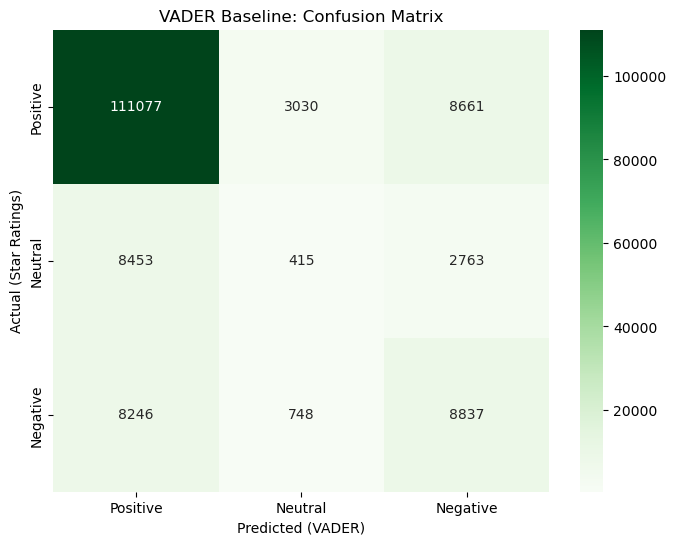

In [4]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map Star Ratings (1-5) to Sentiment (Ground Truth)
def map_stars(rating):
    if rating >= 4: return 'Positive'
    elif rating <= 2: return 'Negative'
    else: return 'Neutral'

# Overwriting to ensure fresh ground truth
df['actual_sentiment'] = df['rating'].apply(map_stars)

# 2. Map VADER Compound Score to Categories 
def map_vader_score(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

# Using your specific column name 'vader_compound'
df['vader_sentiment'] = df['vader_compound'].apply(map_vader_score)

# 3. Calculate Performance Metrics
overall_acc = accuracy_score(df['actual_sentiment'], df['vader_sentiment'])
print(f"Overall VADER Accuracy: {overall_acc:.2%}")

print("\n--- Accuracy by Period ---")
for p in df['period'].unique():
    subset = df[df['period'] == p]
    p_acc = accuracy_score(subset['actual_sentiment'], subset['vader_sentiment'])
    print(f"{p} Accuracy: {p_acc:.2%}")

print("\n--- Full Performance Report ---")
print(classification_report(df['actual_sentiment'], df['vader_sentiment']))

# 4. Visual EDA: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(df['actual_sentiment'], df['vader_sentiment'], labels=['Positive', 'Neutral', 'Negative'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Positive', 'Neutral', 'Negative'], 
            yticklabels=['Positive', 'Neutral', 'Negative'])
plt.title('VADER Baseline: Confusion Matrix')
plt.xlabel('Predicted (VADER)')
plt.ylabel('Actual (Star Ratings)')
plt.show()

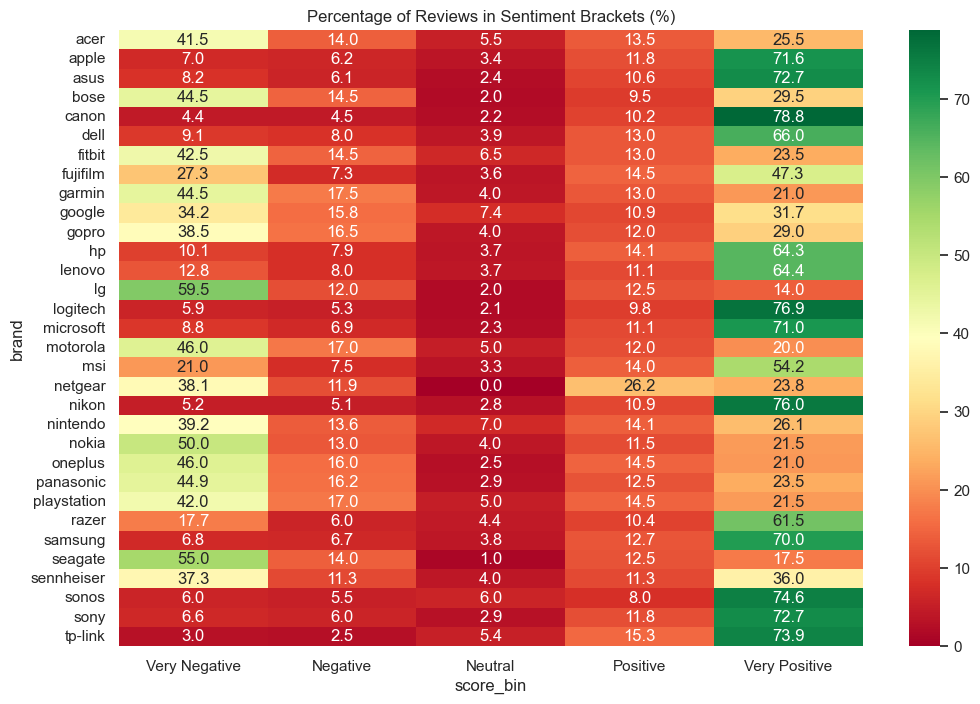

In [8]:
# Create bins for the -1 to 1 range
df['score_bin'] = pd.cut(df['vader_compound'], bins=[-1, -0.5, -0.05, 0.05, 0.5, 1], 
                         labels=['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])

# Create a heatmap table
heatmap_data = pd.crosstab(df['brand'], df['score_bin'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.1f')
plt.title('Percentage of Reviews in Sentiment Brackets (%)')
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\2491344861.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv(file_path)


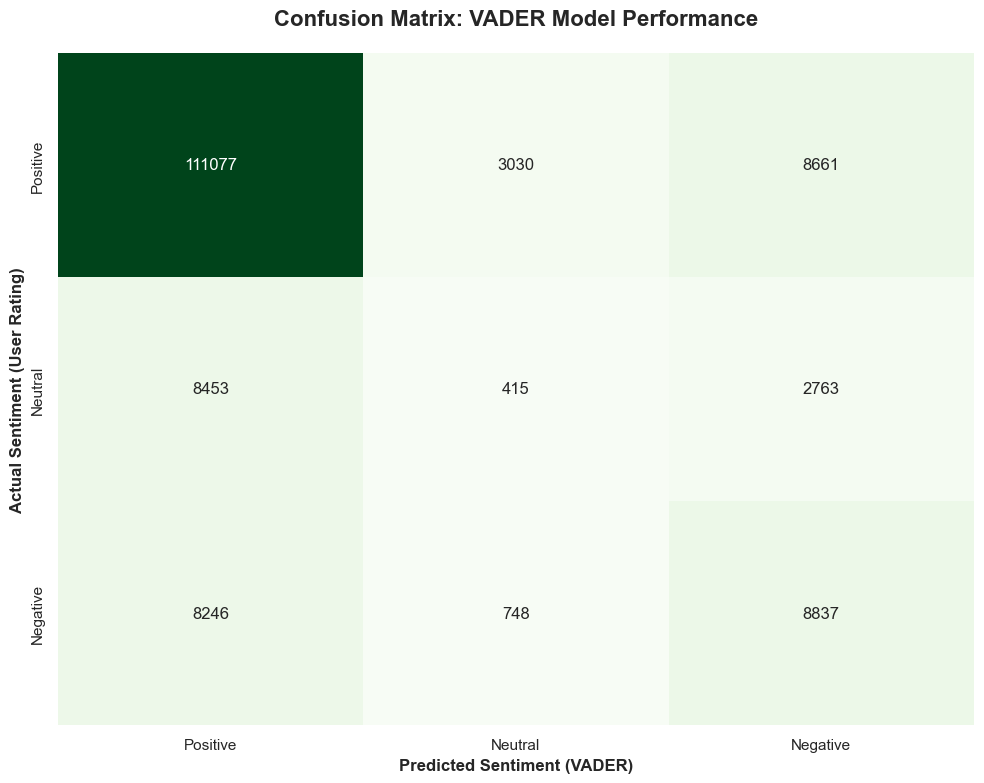

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load the dataset
file_path = '../data/processed/final_master_sentiment_report.csv'
df_final = pd.read_csv(file_path)

# 2. Define the labels in flipped order (Positive first)
labels = ['Positive', 'Neutral', 'Negative']

# 3. Calculate the Confusion Matrix for VADER
# Truth: rating_sentiment | Predicted: vader_sentiment
cm_vader = confusion_matrix(df_final['rating_sentiment'], df_final['vader_sentiment'], labels=labels)

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_vader, 
    annot=True, 
    fmt='d', 
    cmap='Greens', # Using Green to distinguish it from the Blue BERT matrix
    xticklabels=labels, 
    yticklabels=labels,
    cbar=False
)

# 5. Styling
plt.title('Confusion Matrix: VADER Model Performance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Sentiment (VADER)', fontsize=12, fontweight='bold')
plt.ylabel('Actual Sentiment (User Rating)', fontsize=12, fontweight='bold')

plt.tight_layout()

# 6. Save and Show
plt.savefig('../data/processed/vader_confusion_matrix_flipped.png', dpi=300)
plt.show()

In [14]:
# Calculate descriptive stats for both periods
vader_stats = df.groupby('period')['vader_compound'].describe()

# Add a check for the percentage of reviews that are truly negative (<-0.05)
neg_pct = df[df['vader_compound'] < -0.05].groupby('period').size() / df.groupby('period').size() * 100
vader_stats['% Negative'] = neg_pct

print("--- VADER SCORE SUMMARY (-1 TO 1) ---")
print(vader_stats.round(3))

--- VADER SCORE SUMMARY (-1 TO 1) ---
            count   mean    std    min    25%   50%    75%  max  % Negative
period                                                                     
Past     146494.0  0.619  0.488 -0.998  0.493  0.84  0.950  1.0      11.686
Present    5736.0 -0.104  0.688 -0.998 -0.772 -0.24  0.604  1.0      54.725


**BERT**

In [20]:
import importlib
import sentiment_models
importlib.reload(sentiment_models)

from sentiment_models import BERTAnalyzer
print("✅ BERTAnalyzer successfully imported!")

✅ BERTAnalyzer successfully imported!


In [23]:
import importlib
import sentiment_models

# 1. Force Python to reload the file from the disk
importlib.reload(sentiment_models)

# 2. Re-import the class
from sentiment_models import BERTAnalyzer

# 3. Re-initialize the model (this won't re-download it, just re-load it into memory)
bert_model = BERTAnalyzer()

print("✅ BERTAnalyzer reloaded with analyze_batch support!")

Initializing BERT (bert-base-multilingual-uncased-sentiment)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ BERTAnalyzer reloaded with analyze_batch support!


In [28]:
# List all columns to see the exact names
print("Current Columns:", df.columns.tolist())

# Try to find the text columns (adjust names if they are different)
text_col = 'clean_text' 
# If 'preprocessed_text' is missing, let's look for any other text column
other_cols = [c for c in df.columns if 'text' in c or 'review' in c]

print("\n--- TEXT SAMPLE COMPARISON ---")
for col in other_cols:
    print(f"[{col}]: {df[col].iloc[0]}")

Current Columns: ['brand', 'review_text', 'rating', 'date', 'source', 'period', 'rating_sentiment', 'clean_text', 'vader_compound', 'vader_sentiment', 'actual_sentiment', 'score_bin', 'bert_sentiment']

--- TEXT SAMPLE COMPARISON ---
[review_text]: Just got my phone 2 days ago, i am really enjoying it
[clean_text]: got phone day ago really enjoying


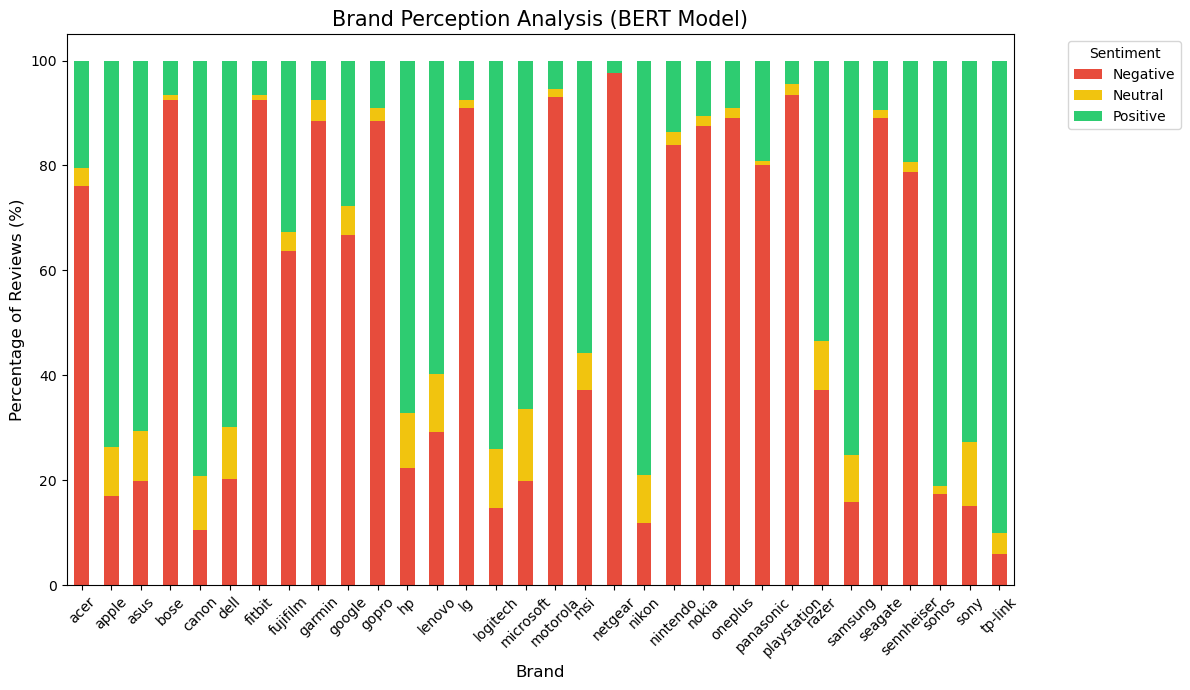

--- 🏆 BRAND SENTIMENT RANKING (MOST POSITIVE) ---
brand
tp-link        90.147783
sonos          81.094527
canon          79.242490
nikon          78.934270
samsung        75.226134
logitech       74.008147
apple          73.591979
sony           72.679358
asus           70.700637
dell           69.847050
hp             67.188179
microsoft      66.420382
lenovo         59.734964
msi            55.802862
razer          53.385417
fujifilm       32.727273
google         27.722772
acer           20.500000
sennheiser     19.333333
panasonic      19.117647
nintendo       13.567839
nokia          10.500000
seagate         9.500000
oneplus         9.000000
gopro           9.000000
lg              7.500000
garmin          7.500000
fitbit          6.500000
bose            6.500000
motorola        5.500000
playstation     4.500000
netgear         2.380952
Name: Positive, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data by Brand and BERT Sentiment
brand_sentiment = df_final.groupby(['brand', 'bert_sentiment']).size().unstack(fill_value=0)

# 2. Convert to percentages so we can compare brands of different sizes
brand_sentiment_pct = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0) * 100

# 3. Create a beautiful stacked bar chart
plt.figure(figsize=(12, 7))
brand_sentiment_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#f1c40f', '#2ecc71'], ax=plt.gca())

plt.title('Brand Perception Analysis (BERT Model)', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the chart for your report
plt.savefig('../data/processed/brand_perception_bert_final.png')
plt.show()

# 4. Print the "Winner"
positive_scores = brand_sentiment_pct['Positive'].sort_values(ascending=False)
print("--- 🏆 BRAND SENTIMENT RANKING (MOST POSITIVE) ---")
print(positive_scores)

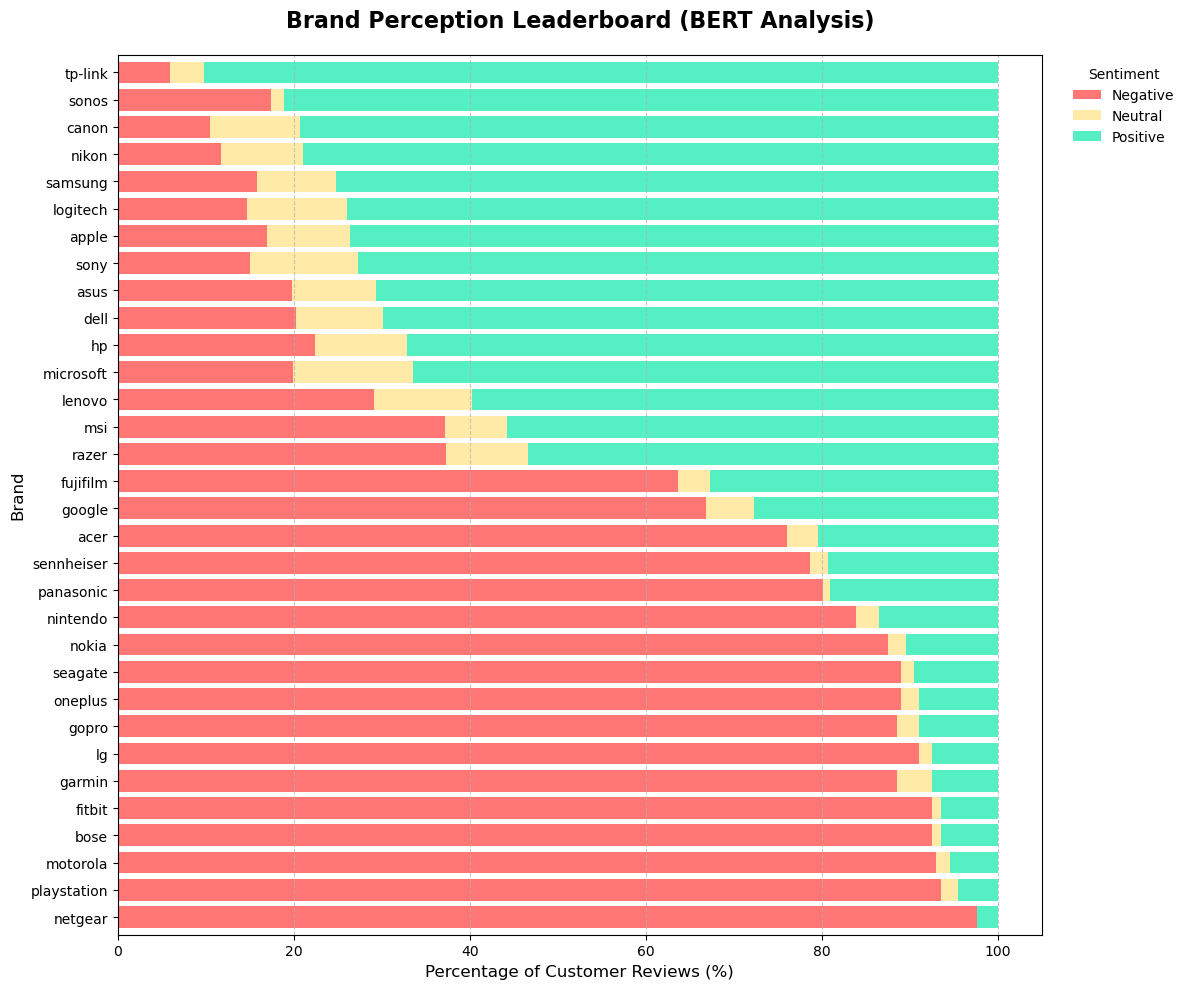

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data (Group and Normalize to 100%)
brand_sentiment = df_final.groupby(['brand', 'bert_sentiment']).size().unstack(fill_value=0)
# Sorting by Positive sentiment makes the chart much more insightful
brand_sentiment_pct = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0) * 100
brand_sentiment_pct = brand_sentiment_pct.sort_values(by='Positive', ascending=True)

# 2. Plotting Horizontally
plt.figure(figsize=(12, 10)) # Increased height for brand readability
brand_sentiment_pct.plot(
    kind='barh', 
    stacked=True, 
    color=['#ff7675', '#ffeaa7', '#55efc4'], # Modern Red, Yellow, Green palette
    ax=plt.gca(),
    width=0.8
)

# 3. Styling the Chart
plt.title('Brand Perception Leaderboard (BERT Analysis)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage of Customer Reviews (%)', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Add gridlines for the x-axis only to help guide the eye
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

# 4. Save and Show
plt.savefig('../data/processed/horizontal_brand_perception_bert.png', dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\753519813.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv(file_path)


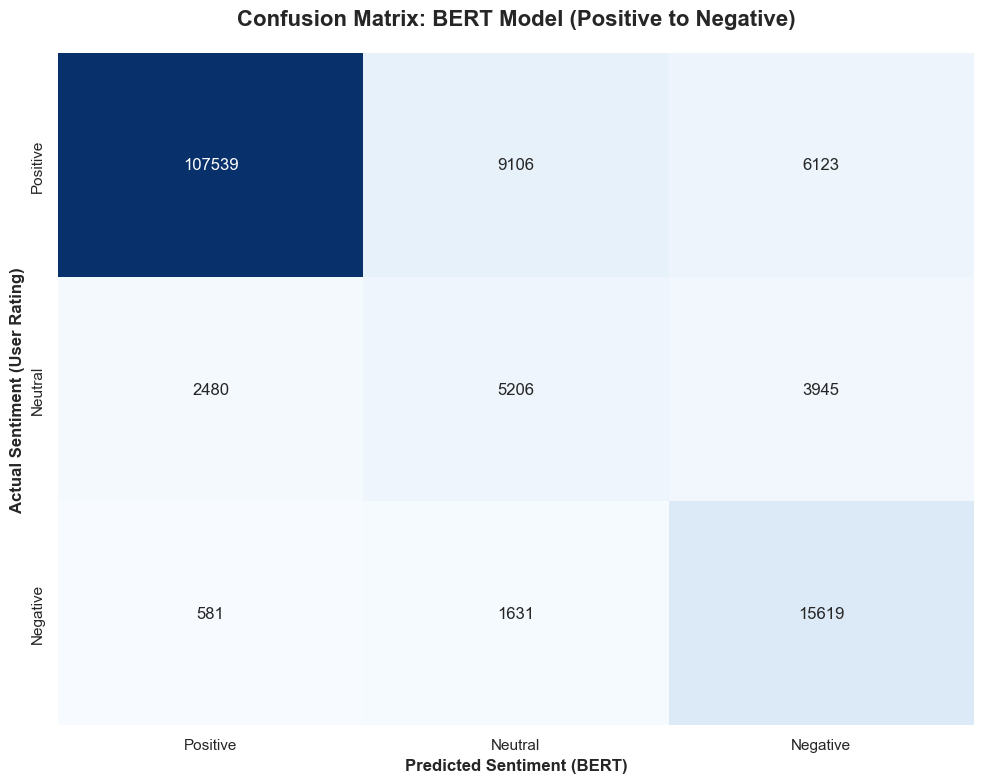

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load your final dataset
file_path = '../data/processed/final_master_sentiment_report.csv'
df_final = pd.read_csv(file_path)

# 2. Define the labels in reverse order (Positive first)
labels = ['Positive', 'Neutral', 'Negative']

# 3. Calculate the Confusion Matrix
cm = confusion_matrix(df_final['rating_sentiment'], df_final['bert_sentiment'], labels=labels)

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels,
    cbar=False
)

# 5. Styling
plt.title('Confusion Matrix: BERT Model (Positive to Negative)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Sentiment (BERT)', fontsize=12, fontweight='bold')
plt.ylabel('Actual Sentiment (User Rating)', fontsize=12, fontweight='bold')

plt.tight_layout()

# 6. Save and Show
plt.savefig('../data/processed/bert_confusion_matrix_flipped.png', dpi=300)
plt.show()

RoBERTa

In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Load the file
df_final = pd.read_csv('../data/processed/master_sentiment_with_roberta.csv')
truth = df_final['rating_sentiment']

print(f"--- 🚀 RoBERTa PERFORMANCE ---")
roberta_acc = accuracy_score(truth, df_final['roberta_sentiment'])
print(f"RoBERTa Accuracy: {roberta_acc:.2%}")

print("\n--- RoBERTa DETAILS ---")
print(classification_report(truth, df_final['roberta_sentiment']))

C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\3923955906.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('../data/processed/master_sentiment_with_roberta.csv')


--- 🚀 RoBERTa PERFORMANCE ---
RoBERTa Accuracy: 78.12%

--- RoBERTa DETAILS ---
              precision    recall  f1-score   support

    Negative       0.56      0.75      0.64     17831
     Neutral       0.15      0.24      0.18     11631
    Positive       0.94      0.84      0.89    122768

    accuracy                           0.78    152230
   macro avg       0.55      0.61      0.57    152230
weighted avg       0.83      0.78      0.80    152230



Ensemble model

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Load both processed files
# Adjust these names if your files are named slightly differently in /processed/
df_bert = pd.read_csv('../data/processed/final_master_sentiment_report.csv') 
df_rob = pd.read_csv('../data/processed/master_sentiment_with_roberta.csv')

# 2. Merge BERT and RoBERTa results into one DataFrame
df_ultimate = df_bert.copy()
df_ultimate['roberta_sentiment'] = df_rob['roberta_sentiment']

# 3. Define the Weighted Voting Logic (BERT=2, Others=1)
def weighted_vote(row):
    scores = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
    
    # Check for NaNs just in case
    b_sent = str(row['bert_sentiment'])
    v_sent = str(row['vader_sentiment'])
    r_sent = str(row['roberta_sentiment'])
    
    # Assign Weights
    if b_sent in scores: scores[b_sent] += 2
    if v_sent in scores: scores[v_sent] += 1
    if r_sent in scores: scores[r_sent] += 1
    
    # Tie-breaker: If there's a tie, the max function returns the first one found.
    # Because we want BERT to win ties, we could prioritize it, 
    # but with weight 2, BERT usually wins anyway.
    return max(scores, key=scores.get)

# 4. Apply Ensemble
print("⚖️ Creating Weighted Ensemble...")
df_ultimate['weighted_ensemble'] = df_ultimate.apply(weighted_vote, axis=1)

# 5. Calculate Final Accuracy
truth = df_ultimate['rating_sentiment']
b_acc = accuracy_score(truth, df_ultimate['bert_sentiment'])
w_acc = accuracy_score(truth, df_ultimate['weighted_ensemble'])

print(f"\n--- 🏁 FINAL PROJECT SCOREBOARD ---")
print(f"Original BERT Accuracy: {b_acc:.2%}")
print(f"NEW Weighted Ensemble Accuracy: {w_acc:.2%}")

# 6. Save this as your master file for the project
df_ultimate.to_csv('../data/processed/ultimate_brand_analysis_final.csv', index=False)
print("\n Saved: ultimate_brand_analysis_final.csv")

C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\1306766778.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bert = pd.read_csv('../data/processed/final_master_sentiment_report.csv')
C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\1306766778.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rob = pd.read_csv('../data/processed/master_sentiment_with_roberta.csv')


⚖️ Creating Weighted Ensemble...

--- 🏁 FINAL PROJECT SCOREBOARD ---
Original BERT Accuracy: 84.32%
NEW Weighted Ensemble Accuracy: 86.50%

✅ Saved: ultimate_brand_analysis_final.csv


In [45]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Load both processed files
df_bert = pd.read_csv('../data/processed/final_master_sentiment_report.csv', low_memory=False) 
df_rob = pd.read_csv('../data/processed/master_sentiment_with_roberta.csv', low_memory=False)

# 2. Merge results
df_ultimate = df_bert.copy()
df_ultimate['roberta_sentiment'] = df_rob['roberta_sentiment']

# 3. Weighted Voting Logic (BERT=2, Others=1)
def weighted_vote(row):
    scores = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
    b_sent, v_sent, r_sent = str(row['bert_sentiment']), str(row['vader_sentiment']), str(row['roberta_sentiment'])
    
    if b_sent in scores: scores[b_sent] += 2
    if v_sent in scores: scores[v_sent] += 1
    if r_sent in scores: scores[r_sent] += 1
    
    return max(scores, key=scores.get)

# 4. Apply Ensemble
print(" Creating Weighted Ensemble (Weight 2-1-1)...")
df_ultimate['weighted_ensemble'] = df_ultimate.apply(weighted_vote, axis=1)

# 5. FINAL SCOREBOARD (Accuracy + F1 + Recall)
truth = df_ultimate['rating_sentiment']
ensemble_preds = df_ultimate['weighted_ensemble']

print(f"\n---  FINAL PROJECT SCOREBOARD ---")
print(f"Final Ensemble Accuracy: {accuracy_score(truth, ensemble_preds):.2%}")

print("\n---  DETAILED TECHNICAL METRICS (F1 & RECALL) ---")
# This generates the F1 and Recall for every category
report = classification_report(truth, ensemble_preds)
print(report)

# 6. Save final file
df_ultimate.to_csv('../data/processed/ultimate_brand_analysis_final.csv', index=False)
print("\n Saved: ultimate_brand_analysis_final.csv")

 Creating Weighted Ensemble (Weight 2-1-1)...

---  FINAL PROJECT SCOREBOARD ---
Final Ensemble Accuracy: 86.50%

---  DETAILED TECHNICAL METRICS (F1 & RECALL) ---
              precision    recall  f1-score   support

    Negative       0.66      0.81      0.73     17831
     Neutral       0.36      0.31      0.33     11631
    Positive       0.94      0.93      0.93    122768

    accuracy                           0.86    152230
   macro avg       0.66      0.68      0.67    152230
weighted avg       0.87      0.86      0.86    152230


 Saved: ultimate_brand_analysis_final.csv


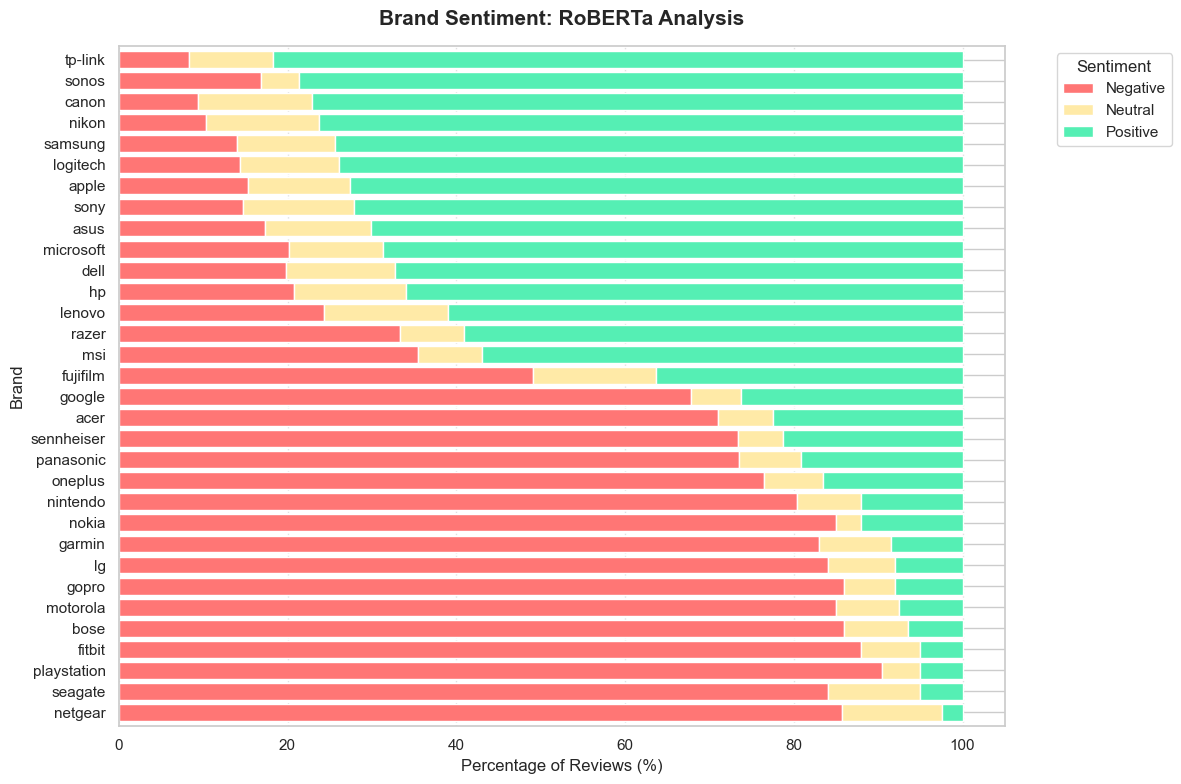

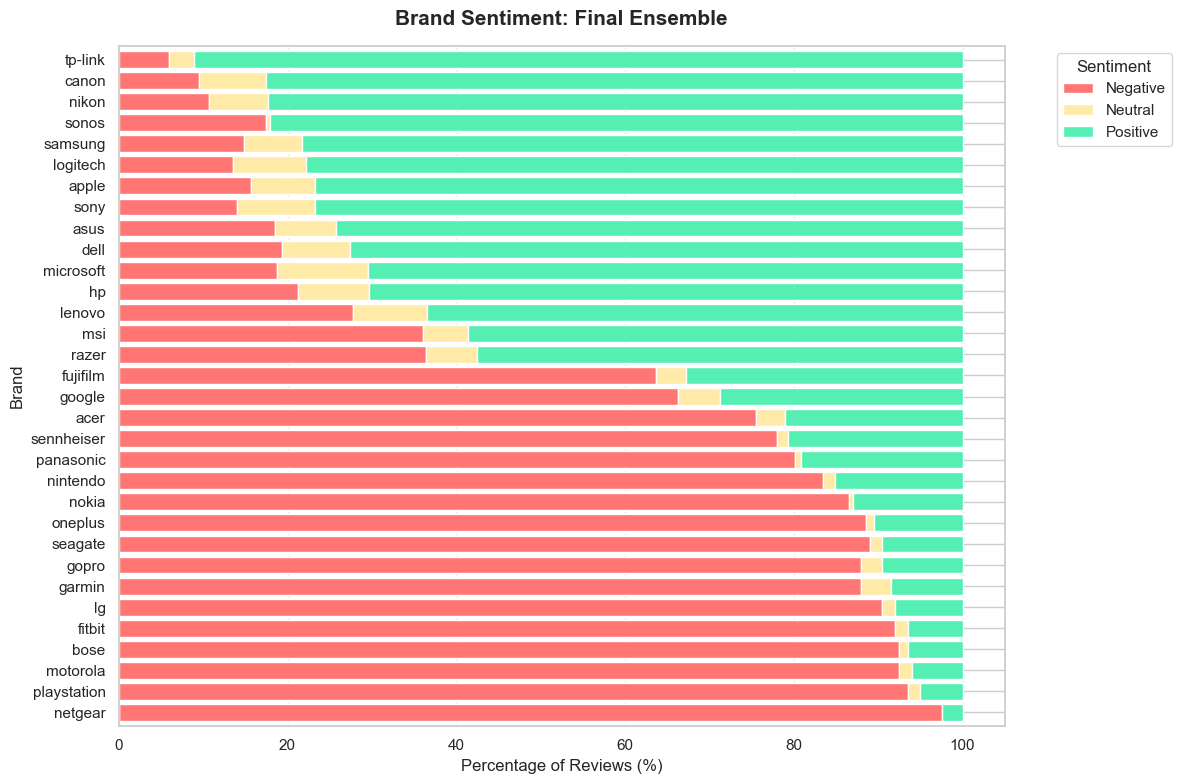

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Load the data
# Using low_memory=False to handle the mixed type warning we saw earlier
df_master = pd.read_csv('../data/processed/ultimate_brand_analysis_final.csv', low_memory=False)
df_deb = pd.read_csv('../data/processed/master_sentiment_with_deberta.csv', low_memory=False)

# 2. Sync DeBERTa into the master
df_master['deberta_sentiment'] = df_deb['deberta_sentiment']

# 3. Optimized Ensemble Logic (BERT weight 3, others 1)
def optimized_ensemble(row):
    scores = {'Positive': 0, 'Neutral': 0, 'Negative': 0}
    scores[str(row['bert_sentiment'])] += 3
    scores[str(row['vader_sentiment'])] += 1
    scores[str(row['roberta_sentiment'])] += 1
    scores[str(row['deberta_sentiment'])] += 1
    return max(scores, key=scores.get)

df_master['final_ensemble'] = df_master.apply(optimized_ensemble, axis=1)

# 4. Save the absolute final version
df_master.to_csv('../data/processed/PROJECT_FINAL_CONSOLIDATED.csv', index=False)

# 5. Define Plotting Function (Fixed Syntax)
def plot_brand_sentiment(col_name, title):
    # Prepare data
    brand_data = df_master.groupby(['brand', col_name]).size().unstack(fill_value=0)
    # Ensure columns exist even if a model missed one
    for label in ['Negative', 'Neutral', 'Positive']:
        if label not in brand_data.columns:
            brand_data[label] = 0
    
    # Reorder columns and normalize to %
    brand_data = brand_data[['Negative', 'Neutral', 'Positive']]
    brand_pct = brand_data.div(brand_data.sum(axis=1), axis=0) * 100
    brand_pct = brand_pct.sort_values(by='Positive', ascending=True)

    # Plotting
    plt.figure(figsize=(12, 8))
    brand_pct.plot(kind='barh', stacked=True, 
                   color=['#ff7675', '#ffeaa7', "#55efb4"], 
                   ax=plt.gca(), width=0.8)
    
    plt.title(title, fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Percentage of Reviews (%)')
    plt.ylabel('Brand')
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 6. Generate the Two Comparison Graphs
plot_brand_sentiment('roberta_sentiment', 'Brand Sentiment: RoBERTa Analysis')
plot_brand_sentiment('final_ensemble', 'Brand Sentiment: Final Ensemble')

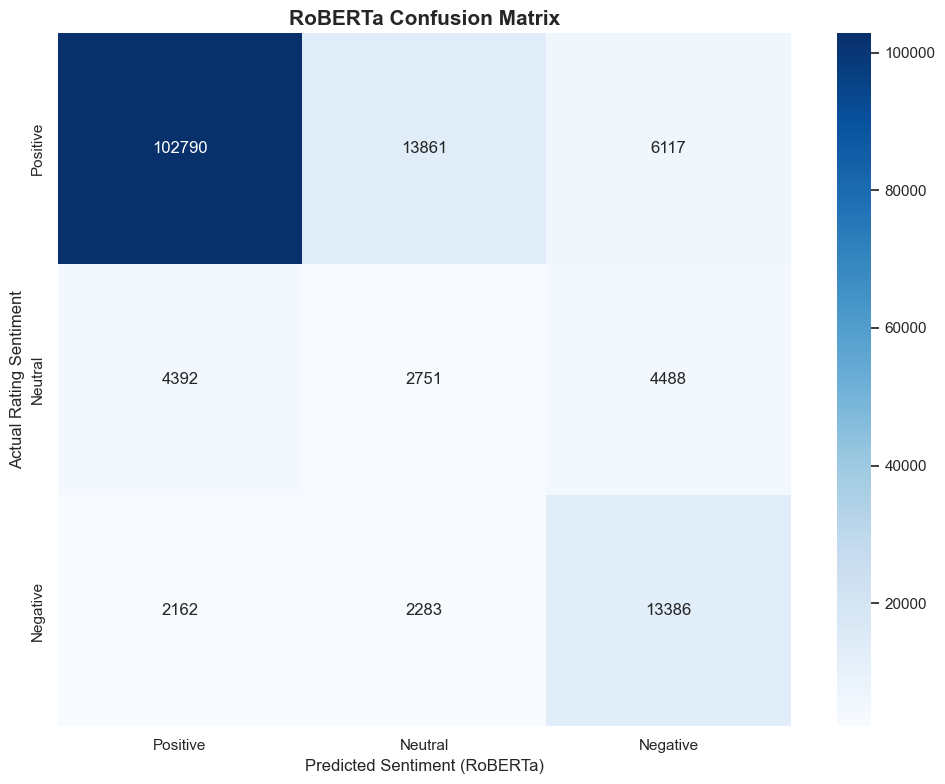

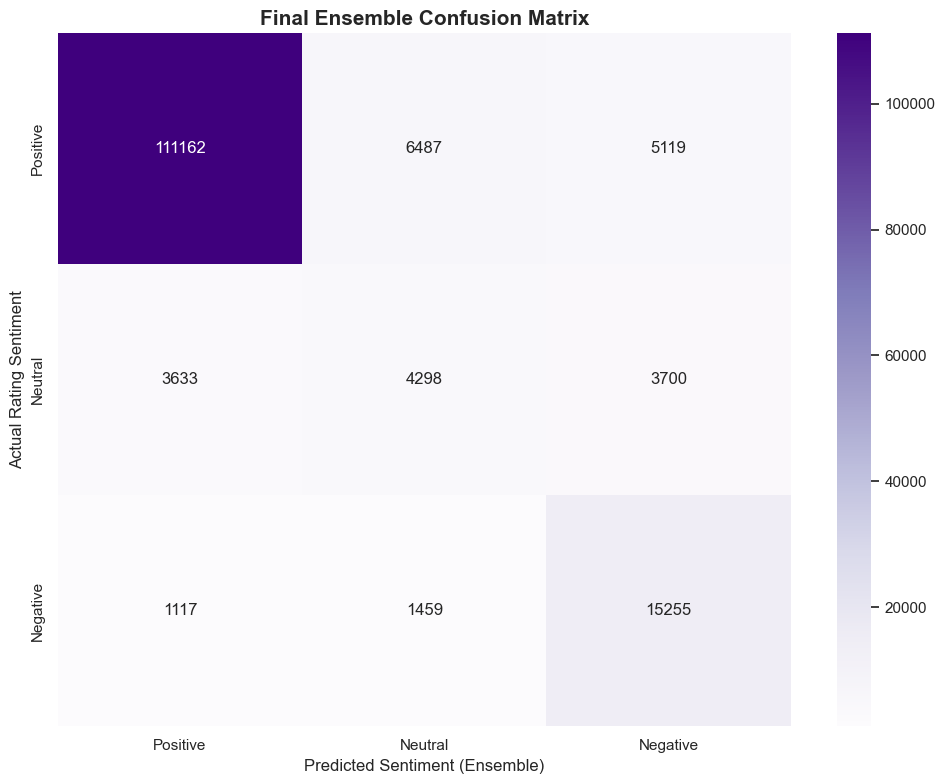

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load final data
df_final = pd.read_csv('../data/processed/PROJECT_FINAL_CONSOLIDATED.csv', low_memory=False)
labels = ['Positive', 'Neutral', 'Negative']

# --- RO-BERTA CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
cm_rob = confusion_matrix(df_final['rating_sentiment'], df_final['roberta_sentiment'], labels=labels)
sns.heatmap(cm_rob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('RoBERTa Confusion Matrix', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Sentiment (RoBERTa)')
plt.ylabel('Actual Rating Sentiment')
plt.tight_layout()
plt.savefig('../data/processed/eda_performance_roberta.png', dpi=300)
plt.show()

# --- ENSEMBLE CONFUSION MATRIX ---
plt.figure(figsize=(10, 8))
cm_ens = confusion_matrix(df_final['rating_sentiment'], df_final['final_ensemble'], labels=labels)
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title('Final Ensemble Confusion Matrix', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Sentiment (Ensemble)')
plt.ylabel('Actual Rating Sentiment')
plt.tight_layout()
plt.savefig('../data/processed/eda_performance_ensemble.png', dpi=300)
plt.show()

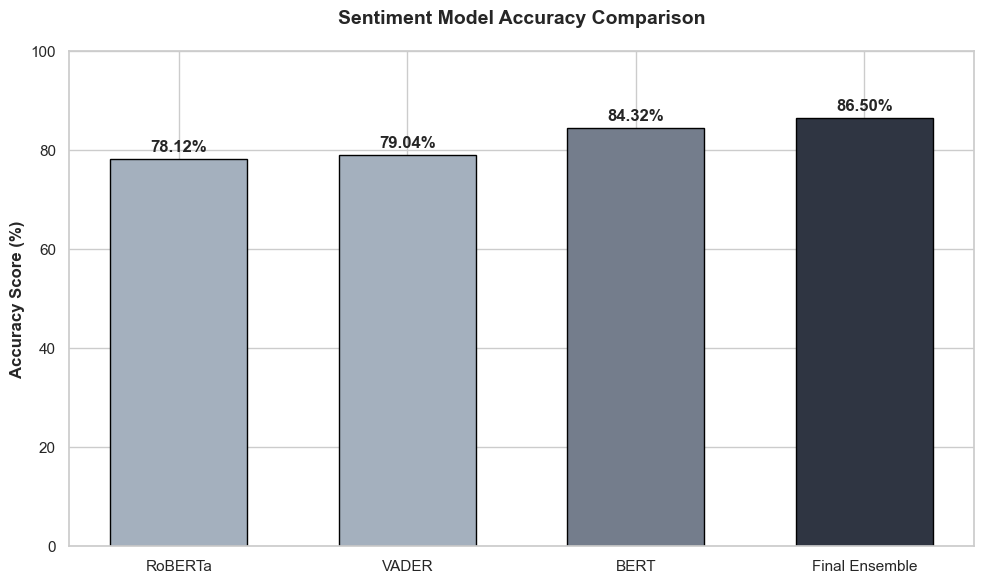

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy data excluding DeBERTa
accuracy_data = {
    'Model': ['RoBERTa', 'VADER', 'BERT', 'Final Ensemble'],
    'Accuracy': [78.12, 79.04, 84.32, 86.50]
}
df_acc = pd.DataFrame(accuracy_data).sort_values(by='Accuracy')

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plotting
colors = ['#a4b0be', '#a4b0be', '#747d8c', '#2f3542']
bars = plt.bar(df_acc['Model'], df_acc['Accuracy'], color=colors, edgecolor='black', width=0.6)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Sentiment Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score (%)', fontweight='bold')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

✅ Found 13 common brands. Filtering data...


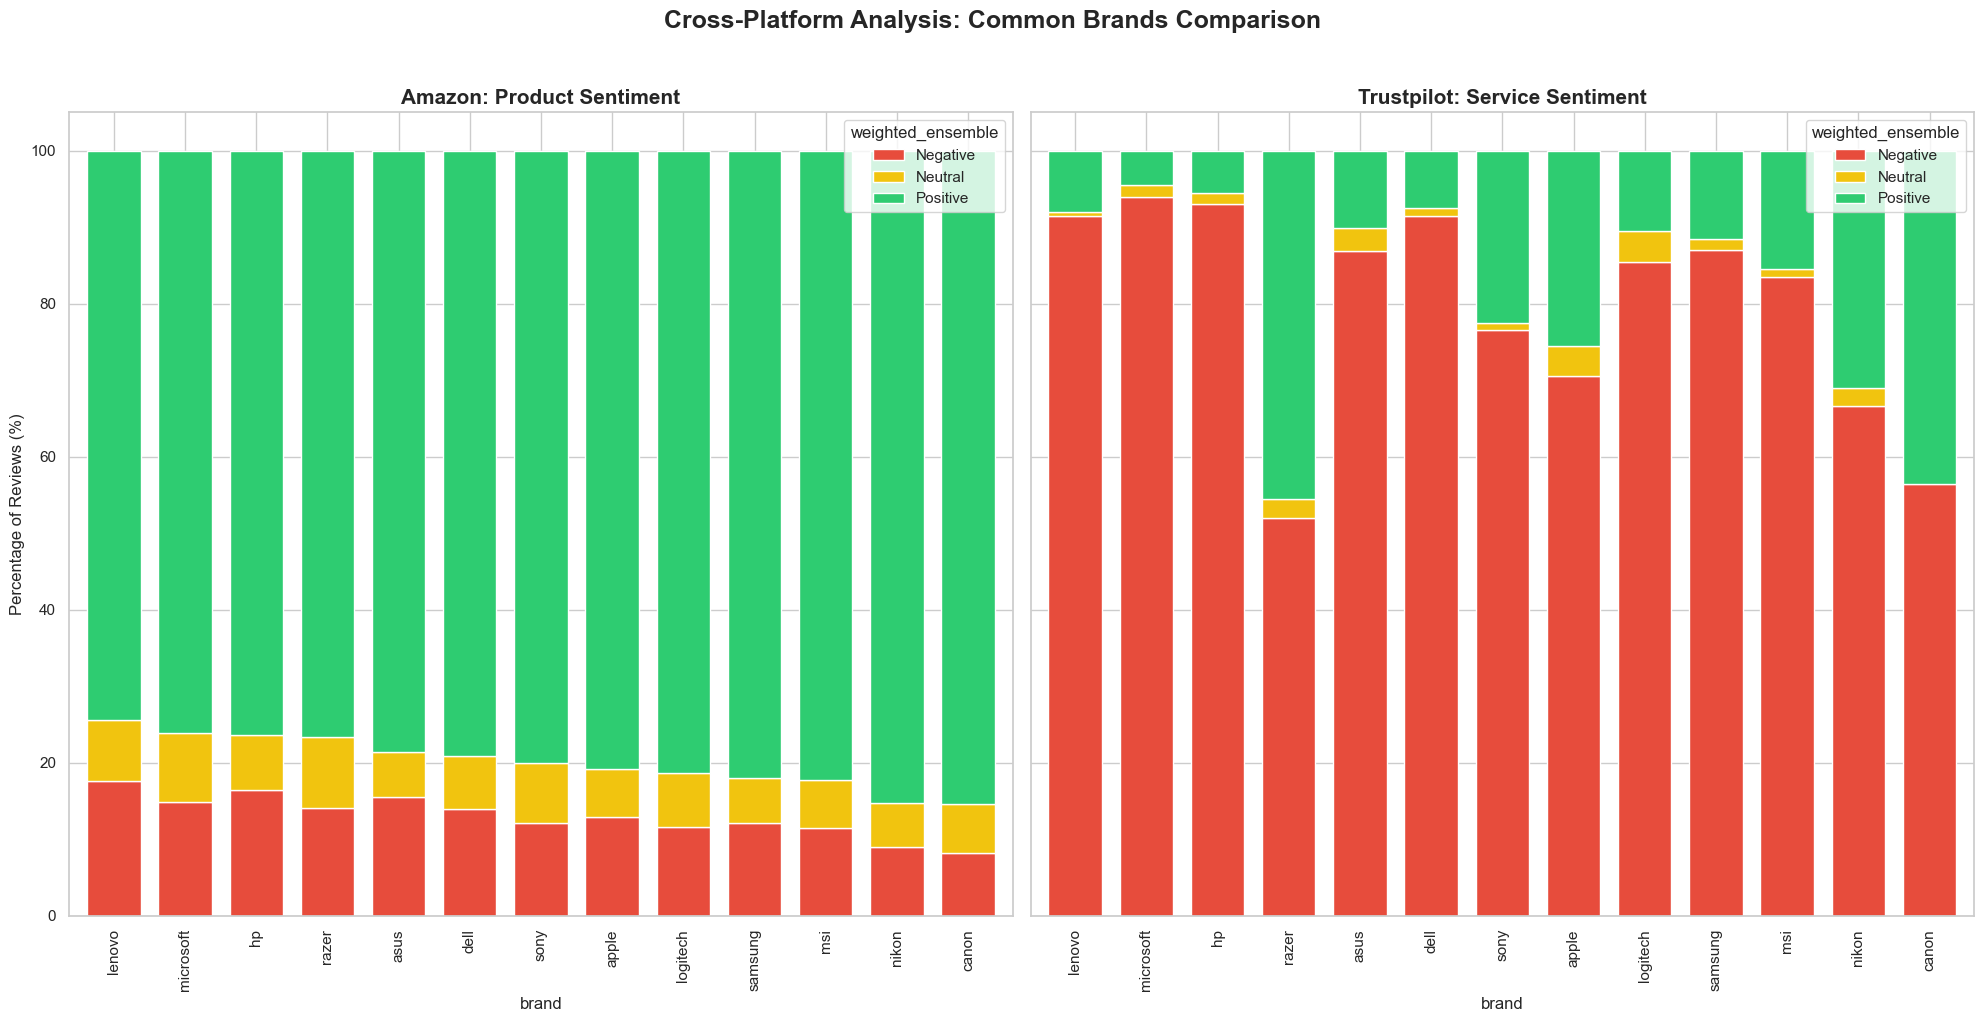


--- 📊 SENTIMENT SHIFT (Amazon vs Trustpilot) ---
           Amazon Positive %  Trustpilot Positive %  Shift (%)
brand                                                         
dell               79.152845               7.500000 -71.652845
microsoft          76.091503               4.500000 -71.591503
hp                 76.374375               5.500000 -70.874375
logitech           81.351704              10.500000 -70.851704
samsung            82.006527              11.500000 -70.506527
asus               78.581778              10.050251 -68.531527
msi                82.284382              15.500000 -66.784382
lenovo             74.347333               8.000000 -66.347333
sony               80.031180              22.500000 -57.531180
apple              80.754215              25.500000 -55.254215
nikon              85.193370              31.034483 -54.158887
canon              85.393749              43.548387 -41.845362
razer              76.630435              45.500000 -31.130435


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the consolidated data
df = pd.read_csv('../data/processed/ultimate_brand_analysis_final.csv', low_memory=False)

# 2. Identify common brands (Intersection)
amazon_brands = set(df[df['source'].str.contains('Amazon', case=False, na=False)]['brand'].unique())
tp_brands = set(df[df['source'].str.contains('Trustpilot', case=False, na=False)]['brand'].unique())
common_brands = sorted(list(amazon_brands.intersection(tp_brands)))

print(f"✅ Found {len(common_brands)} common brands. Filtering data...")

# 3. Filter for common brands only
df_common = df[df['brand'].isin(common_brands)].copy()

def get_platform_stats(data):
    # Grouping and normalizing to 100%
    stats = data.groupby(['brand', 'weighted_ensemble']).size().unstack(fill_value=0)
    for col in ['Negative', 'Neutral', 'Positive']:
        if col not in stats.columns: stats[col] = 0
    stats = stats[['Negative', 'Neutral', 'Positive']]
    return stats.div(stats.sum(axis=1), axis=0) * 100

# 4. Generate stats for both sources
amz_stats = get_platform_stats(df_common[df_common['source'].str.contains('Amazon', case=False)])
tp_stats = get_platform_stats(df_common[df_common['source'].str.contains('Trustpilot', case=False)])

# 5. Side-by-Side Vertical Comparison Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
order = amz_stats.sort_values(by='Positive', ascending=True).index

# Plot Amazon
amz_stats.loc[order].plot(kind='bar', stacked=True, color=['#e74c3c', '#f1c40f', '#2ecc71'], ax=ax[0], width=0.75)
ax[0].set_title('Amazon: Product Sentiment', fontsize=15, fontweight='bold')
ax[0].set_ylabel('Percentage of Reviews (%)')

# Plot Trustpilot
tp_stats.loc[order].plot(kind='bar', stacked=True, color=['#e74c3c', '#f1c40f', '#2ecc71'], ax=ax[1], width=0.75)
ax[1].set_title('Trustpilot: Service Sentiment', fontsize=15, fontweight='bold')

plt.suptitle('Cross-Platform Analysis: Common Brands Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. Sentiment Shift Summary
shift_df = pd.DataFrame({
    'Amazon Positive %': amz_stats['Positive'],
    'Trustpilot Positive %': tp_stats['Positive'],
    'Shift (%)': tp_stats['Positive'] - amz_stats['Positive']
}).sort_values(by='Shift (%)')

print("\n---  SENTIMENT SHIFT (Amazon vs Trustpilot) ---")
print(shift_df)

C:\Users\madhu\AppData\Local\Temp\ipykernel_19716\530782351.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend_data = df_trend.groupby(['year', 'brand']).apply(calculate_yearly_positive).reset_index()


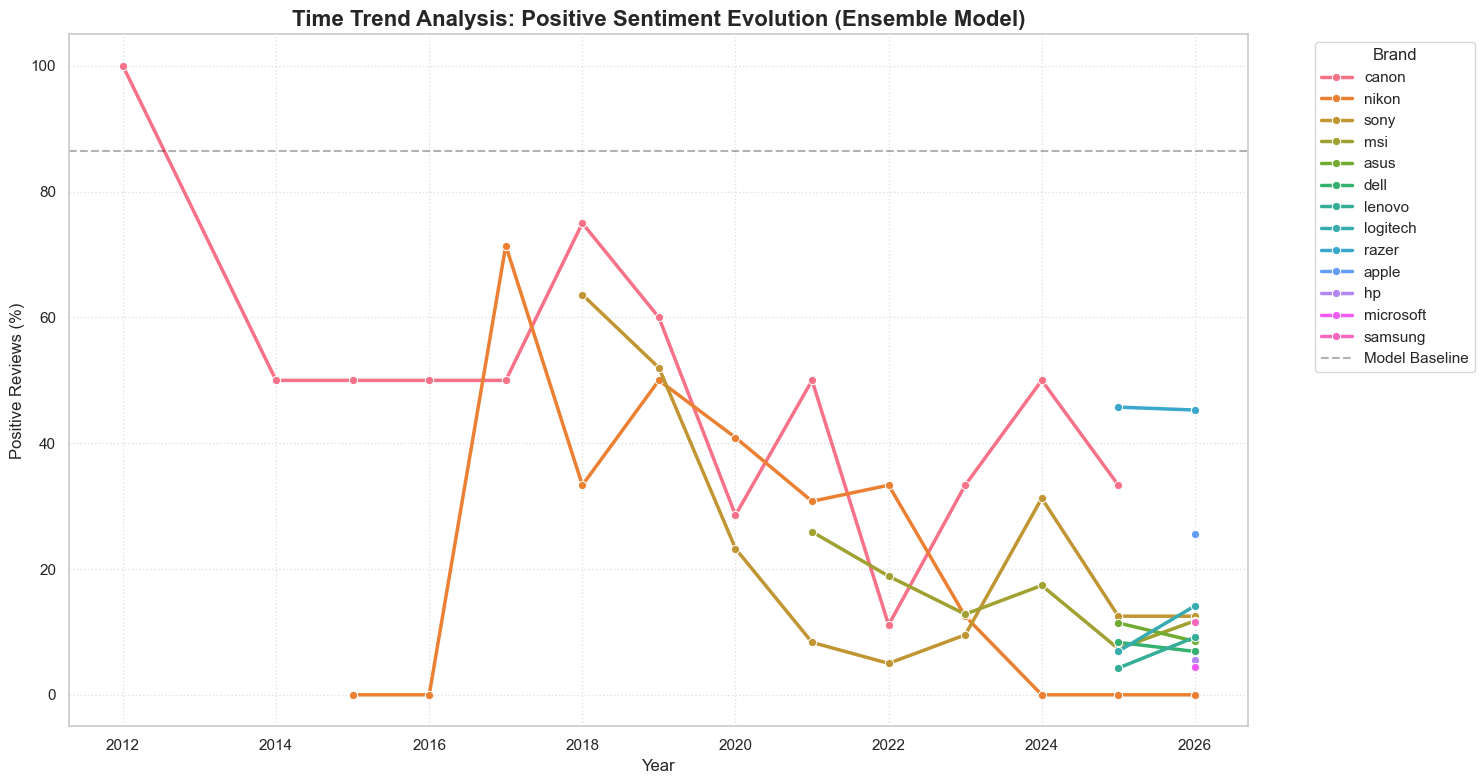

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('../data/processed/ultimate_brand_analysis_final.csv', low_memory=False)

# 2. Convert date column to datetime and extract Year
# Ensure your date column is named 'date'; adjust if it's 'review_date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# 3. Filter for the common brands we identified earlier
amazon_brands = set(df[df['source'].str.contains('Amazon', case=False)]['brand'].unique())
tp_brands = set(df[df['source'].str.contains('Trustpilot', case=False)]['brand'].unique())
common_brands = list(amazon_brands.intersection(tp_brands))
df_trend = df[df['brand'].isin(common_brands)].copy()

# 4. Calculate Yearly Positive Sentiment %
def calculate_yearly_positive(group):
    pos_count = (group['weighted_ensemble'] == 'Positive').sum()
    return (pos_count / len(group)) * 100

trend_data = df_trend.groupby(['year', 'brand']).apply(calculate_yearly_positive).reset_index()
trend_data.columns = ['Year', 'Brand', 'Positive_Rate']

# 5. Visualization: Line Plot of Trends
plt.figure(figsize=(15, 8))
sns.lineplot(data=trend_data, x='Year', y='Positive_Rate', hue='Brand', marker='o', linewidth=2.5)

# Add a reference line for the Ensemble accuracy
plt.axhline(86.5, color='black', linestyle='--', alpha=0.3, label='Model Baseline')

plt.title('Time Trend Analysis: Positive Sentiment Evolution (Ensemble Model)', fontsize=16, fontweight='bold')
plt.ylabel('Positive Reviews (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('../data/processed/sentiment_time_trend.png', dpi=300)
plt.show()